# GLM-5.3-Flash v1.7.0 on 4× CMP 170HX: the long-generation loop is a RecoverSSM off-by-one, fixed with the drafter on

| Measured, TP4 + DFlash2, 4 concurrent long requests | Broken outputs |
|---|---:|
| Recipe v1.7.0 image, spec decode + RecoverSSM on | **13 / 24** |
| Same image, drafter off or RecoverSSM off | 0 / 12 |
| **v1.7.0 image + 2-line fix, drafter and RecoverSSM on** | **0 / 16** |

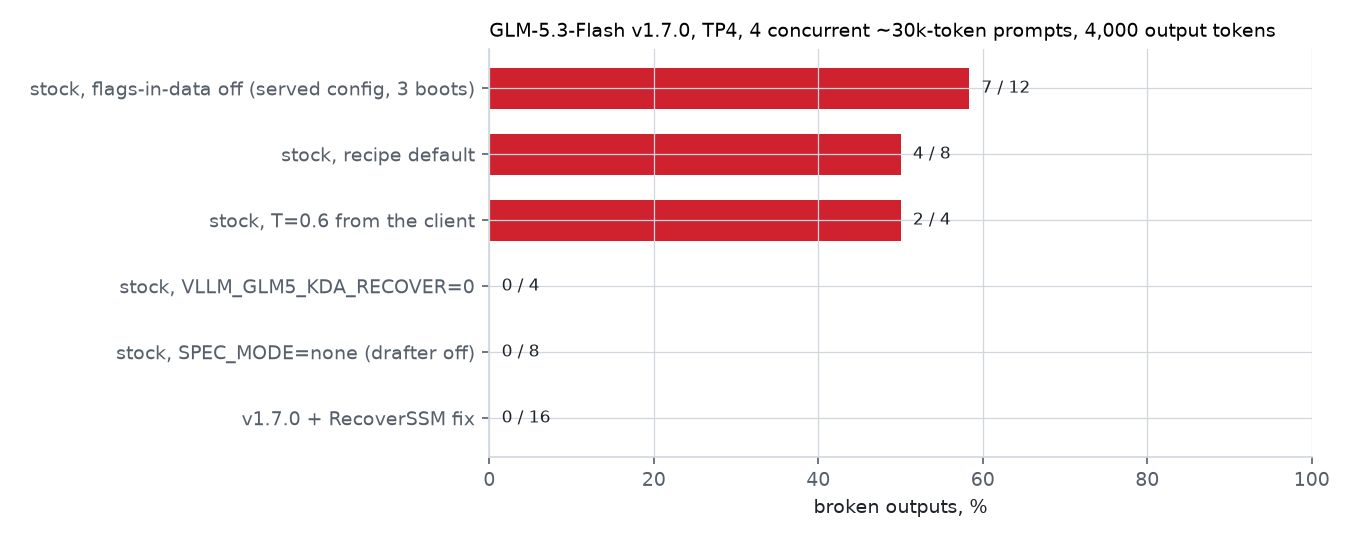

**Verdict (measured):** with recipe v1.7.0 at TP4, long generations under load lose context mid-word and then repeat a token (`locklocklock…`) until `max_tokens`. The cause is not the DFlash2 drafter. It is an off-by-one in the RecoverSSM align commit, which [Morrowmake/glm53-flash-cmp170hx-recipe#7](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe/issues/7) found (community-reported). Two lines fix it ([PixelML/sm80vllm@9522a0efb](https://github.com/PixelML/sm80vllm/commit/9522a0efb60972858811a0883d0c001c6b7087b2)). With the fix, 0 of 16 outputs break, and decode keeps the drafter speed (one user, structured: 438 tok/s; drafter off: 87 tok/s).

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
STOCK_RECEIPTS = "../results/2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm/receipts/glm-v170-tp4-nosys-140"
LIVE = False  # True sends the final request to the endpoint in GLM_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "GLM_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/receipts


In [2]:
# --- Helpers ---
import json, re, math
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

def untail(t):
    t = re.sub(r'"}\s*$', "", t.rstrip())
    try:
        t = json.loads('"' + t + '"')
    except ValueError:
        pass
    return t[-60:]

def samples(name):
    # glm_repro.py prints one line per request, truncated at 400 characters, so read fields with regexes.
    rows = []
    for line in open(f"{RECEIPTS}/repro/{name}.out"):
        if not line.startswith("concurrent"):
            continue
        f = lambda k: (re.search(rf'"{k}": ("[^"]*"|\[[^\]]*\]|null|\d+)', line) or [None, None])[1]
        tail = re.search(r'"tail": "(.*)', line)
        rows.append({"run": name, "i": int(f("i")), "out_tokens": int(f("out_tokens")), "finish": json.loads(f("finish")),
                     "loop": json.loads(f("loop")), "tail": untail(tail.group(1)) if tail else ""})
    return rows

# Manual audit of all 52 outputs: the detector missed one broken output (garbage text, then an early stop).
MANUAL_BROKEN = {("ab-flags0-dflash-r1", 4)}
def broken(s):
    return bool(s["loop"]) or (s["run"], s["i"]) in MANUAL_BROKEN

ARMS = [  # label, receipt files, group
    ("stock, flags-in-data off (served config, 3 boots)", ["iso-flags0", "ab-flags0-dflash-r1", "ab-flags0-dflash-r2"], "bug"),
    ("stock, recipe default", ["ab-default-dflash-r1", "ab-default-dflash-r2"], "bug"),
    ("stock, T=0.6 from the client", ["samp-t06-r1"], "bug"),
    ("stock, VLLM_GLM5_KDA_RECOVER=0", ["iso-recover0"], "off"),
    ("stock, SPEC_MODE=none (drafter off)", ["ab-default-none-r1", "ab-default-none-r2"], "off"),
    ("v1.7.0 + RecoverSSM fix", ["fix-r1", "fix-r2", "fix-r3", "fix-r4"], "fix"),
]
DATA = {lab: [s for n in names for s in samples(n)] for lab, names, _ in ARMS}

def fisher_one_sided(a, n1, b, n2):
    # P(X >= a) for broken counts a of n1 vs b of n2 under the hypergeometric null.
    k, N = a + b, n1 + n2
    return sum(math.comb(n1, x) * math.comb(n2, k - x) for x in range(a, min(n1, k) + 1)) / math.comb(N, k)

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
COL = {"bug": "#cf222e", "off": "#8c959f", "fix": "#1a7f37"}
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})

## 1. TL;DR

- **Measured:** recipe v1.7.0 at TP4 with its default DFlash2 drafter breaks 13 of 24 long generations (4 concurrent requests, 28–34k-token prompts, 4,000 output tokens, sampling from the model's `generation_config`: T=1.0, top_p 0.95). The output switches mid-word to unrelated text, then repeats one token.
- **Measured:** turning the drafter off (`SPEC_MODE=none`) or RecoverSSM off (`VLLM_GLM5_KDA_RECOVER=0`) gives 0 of 12. The flags-in-data all-reduce switch and a lower temperature (0.6) do not help.
- **Community-reported, matches the code:** the RecoverSSM align commit stores the final KDA state in column `floor(x/B)`. The rest of the align path uses `ceil(x/B) − 1`. They differ only when a verify step ends exactly on a 1,152-token block with all drafts accepted. Then the next step reads recurrent state from a block that the request never wrote.
- **Measured:** the 2-line fix gives 0 of 16 broken outputs with the drafter and RecoverSSM on (one-sided Fisher p ≈ 0.0002 against the 13 of 24).
- **Measured:** decode with the fix is 96–97% of the stock v1.7.0 receipt for one user and 99% for eight users. With the drafter off, one user gets 87 tok/s instead of 438.

In [3]:
pins = {
    "fixed engine image": "ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0 (tag vllm-glm53-v170-kdafix-9522a0efb)",
    "fix source": "PixelML/sm80vllm @ 9522a0efb60972858811a0883d0c001c6b7087b2 (branch glm53-v170-kdafix; parent = Morrowmake/vllm-cmp170hx c1ce6491efe53934119d306d0a0501b475458e9b)",
    "fix build recipe": "results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/build/Dockerfile: the stock image by digest + the 2 files from the fix commit, with sha256 checks",
    "stock engine image": "ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e",
    "recipe": "Morrowmake/glm53-flash-cmp170hx-recipe @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0); one local change: --gpus all -> --device nvidia.com/gpu=all (start.sh.patch in the 2026-10-04 v1.7.0 results)",
    "target model": "canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02af36366c23ace8668866ca7775855c1 (MIT)",
    "drafter": "incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eacc1810f76656d1811693ff6c6737d2a (CC BY-NC-ND 4.0)",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB, 74 SMs, BAR1 P2P)",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; container in a privileged LXC sharing the host driver (GPUs by CDI)",
    "topology": "two PLX switches: cards 0-1 PIX, cards 2-3 PIX, cross pairs PHB; PCIe Gen2, three x16 and one x8",
    "power / HBM": "nvidia-smi -pl 140 (host default); HBM 1,728 MHz on all cards (170tune NDIV 64, see the 2026-10-04 v1.7.0 notebook)",
    "recipe .env (all arms)": "LAYOUT=tp4 HOST=0.0.0.0 PORT=8030 P2P=auto GLM5_NCCL_P2P_SYS=0 MODELS_DIR=<models>; per-arm additions in run_ab.sh",
    "fixed run .env": "the line above + IMAGE=<fixed engine image>; boot check PASS (receipts/launch-fixed.txt)",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| fixed engine image | ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0 (tag vllm-glm53-v170-kdafix-9522a0efb) |
| fix source | PixelML/sm80vllm @ 9522a0efb60972858811a0883d0c001c6b7087b2 (branch glm53-v170-kdafix; parent = Morrowmake/vllm-cmp170hx c1ce6491efe53934119d306d0a0501b475458e9b) |
| fix build recipe | results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/build/Dockerfile: the stock image by digest + the 2 files from the fix commit, with sha256 checks |
| stock engine image | ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e |
| recipe | Morrowmake/glm53-flash-cmp170hx-recipe @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0); one local change: --gpus all -> --device nvidia.com/gpu=all (start.sh.patch in the 2026-10-04 v1.7.0 results) |
| target model | canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02af36366c23ace8668866ca7775855c1 (MIT) |
| drafter | incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eacc1810f76656d1811693ff6c6737d2a (CC BY-NC-ND 4.0) |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB, 74 SMs, BAR1 P2P) |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; container in a privileged LXC sharing the host driver (GPUs by CDI) |
| topology | two PLX switches: cards 0-1 PIX, cards 2-3 PIX, cross pairs PHB; PCIe Gen2, three x16 and one x8 |
| power / HBM | nvidia-smi -pl 140 (host default); HBM 1,728 MHz on all cards (170tune NDIV 64, see the 2026-10-04 v1.7.0 notebook) |
| recipe .env (all arms) | LAYOUT=tp4 HOST=0.0.0.0 PORT=8030 P2P=auto GLM5_NCCL_P2P_SYS=0 MODELS_DIR=<models>; per-arm additions in run_ab.sh |
| fixed run .env | the line above + IMAGE=<fixed engine image>; boot check PASS (receipts/launch-fixed.txt) |

## 2. The bug (community-reported cause, checked against the code)

```
verify step: k drafts proposed, all accepted, and num_computed + accepted = k·1152 exactly
   │
   ├─ RecoverSSM commit plan   final_state_col = floor(x / 1152) = k      ◄── column k (not yet written)
   ├─ RecoverSSM postprocess   state_idx       = floor(x / 1152) = k
   └─ rest of align mode       (x − 1) // 1152 = k − 1                    ◄── where the state really is
   │
next step reads recurrent + conv state from column k
   → new Mamba blocks are not zeroed → stale or garbage state in 34 of 45 layers (KDA)
   → mid-word context switch, then a repeated token until max_tokens
```

- Found and analysed in [recipe issue #7](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe/issues/7): every located break was a few tokens after a multiple of 1,152 (community-reported).
- The two `floor` lines are verbatim upstream vLLM (`vllm/models/kimi_k3/nvidia/ops/recoverssm.py`, `vllm/v1/worker/gpu/model_states/recoverssm.py`). Upstream report: [vllm-project/vllm#59933](https://github.com/vllm-project/vllm/issues/59933). Recipe v1.7.0 routes GLM-5 KDA layers through them when `VLLM_GLM5_KDA_RECOVER=1`, which `serve.sh` sets for TP4.
- Inferred: this explains why the bug is intermittent (it needs an exact boundary hit with all drafts accepted) and why it needs both spec decode and RecoverSSM.

The fix:

```diff
-            final_num_computed // mamba_block_size, block_table_width - 1
+            tl.maximum(final_num_computed - 1, 0) // mamba_block_size,
+            block_table_width - 1,
...
-            (num_computed + num_sampled) // MAMBA_BLOCK_SIZE,
+            tl.maximum(num_computed + num_sampled - 1, 0) // MAMBA_BLOCK_SIZE,
```

## 3. A/B (measured)

`glm_repro.py`: 4 concurrent requests, each a 28–34k-token real-text prompt (`bench_long.py` corpus, different offsets) plus a step-by-step arithmetic task, `max_tokens=4000`, no client sampling parameters (so T=1.0, top_p 0.95 from `generation_config.json`), except the T=0.6 arm. A request counts as broken when its text contains a 1–12-character unit repeated 15 or more times, or (manual audit) when it switches to garbage. Each round is 4 requests. TP4, 140 W. One boot per arm, except the served-config arm (3 rounds over 2 boots).

In [4]:
rows, counts = [], {}
for lab, names, grp in ARMS:
    s = DATA[lab]; b = sum(broken(x) for x in s)
    counts[lab] = (b, len(s))
    rows.append([lab, len(names), f"**{b} / {len(s)}**" if grp == "fix" else f"{b} / {len(s)}"])
table(["engine (TP4, DFlash2 unless noted)", "rounds", "broken outputs"], rows)
bug = [counts[l] for l, _, g in ARMS if g == "bug"]; fix = [counts[l] for l, _, g in ARMS if g == "fix"][0]
a, n1 = sum(b for b, _ in bug), sum(n for _, n in bug)
print(f"stock with spec decode + RecoverSSM: {a}/{n1}; fixed: {fix[0]}/{fix[1]}; one-sided Fisher p = {fisher_one_sided(a, n1, fix[0], fix[1]):.5f}")

| engine (TP4, DFlash2 unless noted) | rounds | broken outputs |
|---|---:|---:|
| stock, flags-in-data off (served config, 3 boots) | 3 | 7 / 12 |
| stock, recipe default | 2 | 4 / 8 |
| stock, T=0.6 from the client | 1 | 2 / 4 |
| stock, VLLM_GLM5_KDA_RECOVER=0 | 1 | 0 / 4 |
| stock, SPEC_MODE=none (drafter off) | 2 | 0 / 8 |
| v1.7.0 + RecoverSSM fix | 4 | **0 / 16** |

stock with spec decode + RecoverSSM: 13/24; fixed: 0/16; one-sided Fisher p = 0.00021


In [5]:
# Every output, for audit: finish reason, detected loop (unit, character offset) and the last characters.
table(["run", "req", "out tok", "finish", "loop", "broken", "tail"],
      [[s["run"], s["i"], s["out_tokens"], s["finish"], repr(s["loop"][0]) if s["loop"] else "–", "yes" if broken(s) else "",
        "`" + s["tail"].replace("|", "/").replace("`", "'") + "`"] for lab, _, _ in ARMS for s in DATA[lab]])

| run | req | out tok | finish | loop | broken | tail |
|---|---:|---:|---:|---:|---:|---:|
| iso-flags0 | 4 | 4000 | length | – |  | ` * 9073.0  Let's compute 0.9856474 * 9073.0: 0.9856474 * 900` |
| iso-flags0 | 5 | 4000 | length | – |  | `89793 = 0.019605... let's see: 0.1384604339 * 0.1 = 0.013846` |
| iso-flags0 | 6 | 4000 | length | – |  | `o apparent − mean convention.   Wait, but is that right? Let` |
| iso-flags0 | 7 | 4000 | length | – |  | ` Then 2×0.409×0.0000243 = 0.0000198774. Total 0.16730088. OK` |
| ab-flags0-dflash-r1 | 4 | 3564 | stop | – | yes | `ountered an issue and cannot provide any response right now.` |
| ab-flags0-dflash-r1 | 5 | 4000 | length | ' ' | yes | `dos ni pausas. '''  ### 9. Pruebas  Se pueden añadir pruebas` |
| ab-flags0-dflash-r1 | 6 | 4000 | length | '-' | yes | `ot_1  Hello_1 Hell_1  *The one where I talk about the_1*  ((` |
| ab-flags0-dflash-r1 | 7 | 4000 | length | – |  | ` − x³/6 + x⁵/120 x = 0.7660316 x³ = 0.44969 (0.7660316² = 0.` |
| ab-flags0-dflash-r2 | 4 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-flags0-dflash-r2 | 5 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-flags0-dflash-r2 | 6 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-flags0-dflash-r2 | 7 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-default-dflash-r1 | 4 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-default-dflash-r1 | 5 | 4000 | length | – |  | ` close enough). Good: g ≈ 299.88°.  Similarly check L: 9223.` |
| ab-default-dflash-r1 | 6 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-default-dflash-r1 | 7 | 4000 | length | – |  | `451545.0 (2000-01-01 12:00) to 2024-01-01 12:00 is 8766 days` |
| ab-default-dflash-r2 | 4 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-default-dflash-r2 | 5 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| ab-default-dflash-r2 | 6 | 4000 | length | – |  | `n 42.5631° ≈ 0.67640.  cos 42.5631° = cos(0.7428666) = cos0.` |
| ab-default-dflash-r2 | 7 | 4000 | length | – |  | `6113°).  41.56113° in radians: 41° = 0.71558499 rad; 0.56113` |
| samp-t06-r1 | 4 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| samp-t06-r1 | 5 | 4000 | length | – |  | `8602°.  So L = 223.2389° (approx). Let me be more precise: 0` |
| samp-t06-r1 | 6 | 4000 | length | 'lock' | yes | `locklocklocklocklocklocklocklocklocklocklocklocklocklocklock` |
| samp-t06-r1 | 7 | 4000 | length | – |  | `= 299.880°  **Step 5: Calculate the ecliptic longitude (λ)**` |
| iso-recover0 | 4 | 4000 | length | – |  | `-22 at 240°). Nov 21/22 → λ=240. Going back 18 days at ~1.01` |
| iso-recover0 | 5 | 4000 | length | – |  | `5.0. The date 2024-11-03 12:00 UTC corresponds to JD 2460618` |
| iso-recover0 | 6 | 4000 | length | – |  | `1-01.) Total 8766 days. JD 2024-01-01 12:00 = 2451545 + 8766` |
| iso-recover0 | 7 | 4000 | length | – |  | `4218×0.000322 = 0.644218 − 0.000207 = 0.644011. 0.764842 × 0` |
| ab-default-none-r1 | 4 | 4000 | length | – |  | `ly cos 23.4390° ≈ 0.9174771. For 23.43537°, cos ε = 0.917477` |
| ab-default-none-r1 | 5 | 4000 | length | – |  | `59.76 ≈ 0.866025 − 0.5×0.0041888 = 0.865931 − ... wait: sin(` |
| ab-default-none-r1 | 6 | 4000 | length | – |  | `480.47 = 605.51 → mod 360 = 245.51°. sin Ω = sin 245.51° = −` |
| ab-default-none-r1 | 7 | 4000 | length | – |  | `: 0.4090244 = 0.4 + 0.009 + 0.0000244. (0.4)² = 0.16 (0.009)` |
| ab-default-none-r2 | 4 | 4000 | length | – |  | `× 0.0174532925 = 0.007662... 0.4×0.01745329=0.00698132; 0.03` |
| ab-default-none-r2 | 5 | 4000 | length | – |  | `s(23.43537°). 23.43537° in rad = 23.43537 × 0.0174532925 = 0` |
| ab-default-none-r2 | 6 | 4000 | length | – |  | `) ≈ 0.0021031. So sin 60.1205° ≈ 0.86603 × 0.9999978 + 0.5 ×` |
| ab-default-none-r2 | 7 | 4000 | length | – |  | `+ atan(0.608693/0.7482488) = 180° + atan(0.813459).  atan(0.` |
| fix-r1 | 4 | 4000 | length | – |  | `.01745329: 41 × 0.01745329 = 0.71558489; 0.5611 × 0.01745329` |
| fix-r1 | 5 | 4000 | length | – |  | ` sinΔ, Δ = −0.0042068. cosΔ ≈ 1 − 8.85e-6 ≈ 0.99999115. sinΔ` |
| fix-r1 | 6 | 4000 | length | – |  | ` sin 2g  sin g: g = 299.8795°. sin(299.8795°) = sin(−60.1205` |
| fix-r1 | 7 | 4000 | length | – |  | `  Compute sin(41.5611333°) and cos(41.5611333°).  41.5611333` |
| fix-r2 | 4 | 4000 | length | – |  | ` be precise: 1.915*0.8670750 = 1.6604486. 0.020*0.863915 = 0` |
| fix-r2 | 5 | 4000 | length | – |  | ` 9073.0008 = 23.439 − 0.0036292 = 23.4359708°. ε ≈ 23.4360°.` |
| fix-r2 | 6 | 4000 | length | – |  | `0174532925 = 0.4014257 0.4 × 0.0174532925 = 0.0069813 0.03 ×` |
| fix-r2 | 7 | 4000 | length | – |  | ` - sin0.4 sinΔ = 0.921061*(1 - 4.072e-5) - 0.389418*0.009024` |
| fix-r3 | 4 | 4000 | length | – |  | ` the September equinox instant isn't exactly 180 (it's about` |
| fix-r3 | 5 | 4000 | length | – |  | `1 = 0.92106099 − 0.92106099×4.0718e-5 − 0.003513885 = 0.9210` |
| fix-r3 | 6 | 4000 | length | – |  | `11°), cos λ = −cos(41.5611°).  sin 41.5611°: 41.5611° in rad` |
| fix-r3 | 7 | 4000 | length | – |  | ` compute: sin 59.759°: sin 60° = 0.8660254, Δ = −0.241° = −0` |
| fix-r4 | 4 | 4000 | length | – |  | `2 1.5611 × 0.017453293 = 0.027247... compute: 1.5 × 0.017453` |
| fix-r4 | 5 | 4000 | length | – |  | `roach: sin 41.56° ≈? sin 45 = 0.7071; sin 40 = 0.642788. sin` |
| fix-r4 | 6 | 4000 | length | – |  | `5 = 0.69813170; 1.5611*0.0174532925 = 0.027247... 1.5611*0.0` |
| fix-r4 | 7 | 4000 | length | – |  | `.7482483. So cos ≈ 0.74825.  So sin λ = −0.663419, cos λ = −` |

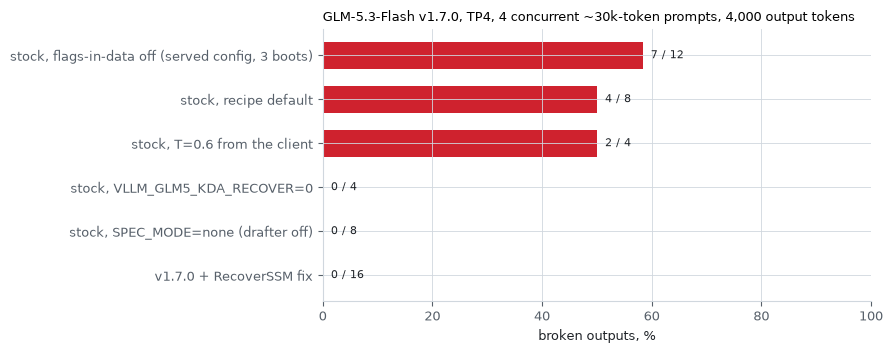

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
labs = [l for l, _, _ in ARMS][::-1]
for y, (lab, _, grp) in enumerate(ARMS[::-1]):
    b, n = counts[lab]
    ax.barh(y, b / n * 100, 0.62, color=COL[grp])
    ax.text(b / n * 100 + 1.5, y, f"{b} / {n}", va="center", fontsize=8, color=INK)
ax.set_yticks(range(len(labs)), labs); ax.set_xlim(0, 100); ax.set_xlabel("broken outputs, %")
ax.set_title("GLM-5.3-Flash v1.7.0, TP4, 4 concurrent ~30k-token prompts, 4,000 output tokens", loc="left", fontsize=9)
fig.tight_layout()
for ext in ("png", "svg"):
    fig.savefig(f"../assets/charts/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm.{ext}", dpi=150)
plt.show()

## 4. Speed with the fix (measured)

`bench_decode.py` from the 2026-10-04 v1.7.0 notebook (MiaAI-Lab prompts, 400 tokens, temperature 0, thinking off; one user = median of 5 runs, eight users = median aggregate of 3 runs). Stock = the served v1.7.0 configuration from that notebook (TP4, `GLM5_NCCL_P2P_SYS=0`, 140 W), a different boot on the same day.

In [7]:
def dec(d, p, c):
    j = json.load(open(f"{d}/decode-{p}-c{c}.json"))
    return j["aggregate_tok_s_median"] if c > 1 else j["tok_s_median"]
PROMPTS = ("structured", "coding", "prose")
rows = []
for c in (1, 8):
    for p in PROMPTS:
        s, f = dec(STOCK_RECEIPTS, p, c), dec(RECEIPTS + "/decode-fixed", p, c)
        rows.append([f"{'1 user' if c == 1 else '8 users, total'}, {p}", f"{s:.1f}", f"{f:.1f}", f"{(f / s - 1) * 100:+.1f}%"])
rows.append(["1 user, prose-length reply, drafter off (SPEC_MODE=none, single request)", "–", "87.4", "–"])
table(["decode tok/s", "stock v1.7.0", "v1.7.0 + fix", "Δ"], rows)

| decode tok/s | stock v1.7.0 | v1.7.0 + fix | Δ |
|---|---:|---:|---:|
| 1 user, structured | 450.8 | 438.2 | -2.8% |
| 1 user, coding | 352.4 | 339.4 | -3.7% |
| 1 user, prose | 184.6 | 178.9 | -3.1% |
| 8 users, total, structured | 762.4 | 756.7 | -0.7% |
| 8 users, total, coding | 616.9 | 614.7 | -0.4% |
| 8 users, total, prose | 498.5 | 494.1 | -0.9% |
| 1 user, prose-length reply, drafter off (SPEC_MODE=none, single request) | – | 87.4 | – |

- Measured: the fix keeps 96–97% of single-user and 99% of eight-user decode against the stock receipt. The two runs were on different boots. Inferred: the 3–4% single-user gap is mostly boot-to-boot variation, because the fix only changes which block column receives a state. A same-boot A/B was not run.
- Measured (one request, not a `bench_decode.py` receipt): with the drafter off, a 1,500-token story decoded at 87.4 tok/s.

## 5. What this does not show (untested)

- Upstream Kimi-K3 with RecoverSSM and prefix caching: same code, not run (no hardware).
- PP4: `kda_recover.py` turns RecoverSSM off for PP ≠ 1, so PP4 is expected to be unaffected (inferred, not re-run).
- Short generations: the repro needs long outputs that cross 1,152-token boundaries. Greedy short prompts did not show the bug in earlier checks.
- Quality benchmarks (GSM8K, HumanEval) with the fix: not re-run.

## 6. Reproduce

Hardware and recipe setup as in the [2026-10-04 v1.7.0 notebook](2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm.ipynb) (4 × CMP 170HX, 64 GiB / 74-SM driver, working BAR1 P2P).

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe
git checkout e61ba680cd6f9497291cafa4ca13ac3ffbdab844
cat > .env <<'EOF'
LAYOUT=tp4
P2P=auto
GLM5_NCCL_P2P_SYS=0
IMAGE=ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0
EOF
./start.sh          # pulls the fixed image, fetches the checkpoints, starts, waits for /health, runs the boot check
```

Rebuild the fixed image yourself instead of pulling it (same two files, checked by sha256):

```bash
docker buildx build -t glm53-v170-kdafix results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/build
```

The full A/B: `results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/run_ab.sh` from the recipe checkout (5 arms, 2 rounds each, about 25 minutes per arm including the restart). One round by hand: `GLM_URL=http://<server>:8030/v1 python3 results/2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm/glm_repro.py`.

WARNING: Do not run `VAR= ./start.sh` to unset an engine switch. The launcher passes the empty value into the container, and vLLM fails at start (`int('')`). Set an explicit value.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints a recorded output from the fixed engine (the end of a 4,000-token reply).

In [8]:
PROMPT = "Compute the equation of time for today at 12:00 UTC step by step."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "glm-5.3-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 4000}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=1800))
    m = resp["choices"][0]["message"]
    print(m.get("content")); print(resp["usage"])
else:
    s = DATA["v1.7.0 + RecoverSSM fix"][0]
    print({k: s[k] for k in ("run", "out_tokens", "finish", "loop")}); print("…" + s["tail"])

{'run': 'fix-r1', 'out_tokens': 4000, 'finish': 'length', 'loop': None}
….01745329: 41 × 0.01745329 = 0.71558489; 0.5611 × 0.01745329


<details><summary>Appendix: notes</summary>

- Run order is in `receipts/repro/run-log-ab.txt` and `run-log-iso.txt` (UTC). The served-config arm includes one fresh-boot round with 0 of 4 broken (`iso-flags0`) and two later rounds with 7 of 8. One round of 4 is not enough to rank switches.
- `SPEC_MODE=none` needs `BOOT_CHECK=0`: the boot check looks for spec-decode counters and stops the server without them.
- The fixed image in the pins was built by copying the same two files into the stock image. `build/Dockerfile` fetches them from the fix commit. A rebuild gives identical file contents (sha256 checked) but a different image digest.
- The drafter licence (CC BY-NC-ND 4.0) restricts commercial use.
</details>